In [72]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn import metrics
import xgboost as xgb
import time
from matplotlib import pyplot as plt
import seaborn as sns

In [15]:
data = pd.read_csv("data_3_values_by_day.csv")
data

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY,refus_tamis
0,2022-01-28 00:00:00,64.767911,10.011742,120.091735,555.430570,15.255906
1,2022-01-28 08:00:00,64.193674,10.009246,120.023860,550.337705,22.246696
2,2022-01-28 16:00:00,63.912885,9.708684,114.701485,547.888626,25.059102
3,2022-01-29 00:00:00,63.892667,9.382377,108.993462,548.397254,23.607689
4,2022-01-29 08:00:00,63.030948,9.503467,109.672496,540.445674,20.491361
...,...,...,...,...,...,...
212,2022-10-19 08:00:00,59.034442,9.738259,103.756132,506.144457,19.743052
213,2022-10-19 16:00:00,58.196467,9.514840,108.719497,498.817430,19.743052
214,2022-10-20 00:00:00,58.120637,9.477183,109.858441,498.298019,19.743052
215,2022-10-20 08:00:00,56.303701,9.846997,101.390345,483.159073,19.743052


<AxesSubplot:>

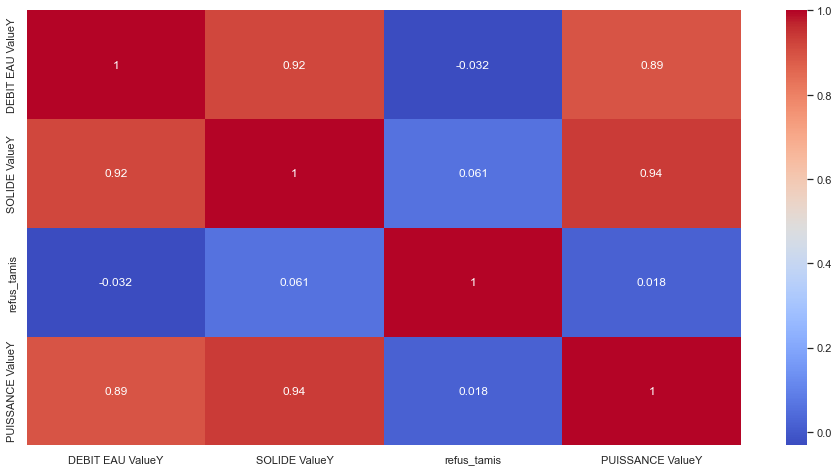

In [73]:
df = data[["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis","PUISSANCE ValueY"]]
sns.set(rc = {'figure.figsize':(16,8)})
sns.heatmap(df.corr(), annot = True, fmt='.2g',cmap= 'coolwarm')

In [16]:
data['Time'] = pd.to_datetime(data['Time'], format="%Y/%m/%d %H:%M:%S")
data.dtypes

Time                datetime64[ns]
COURANT ValueY             float64
DEBIT EAU ValueY           float64
SOLIDE ValueY              float64
PUISSANCE ValueY           float64
refus_tamis                float64
dtype: object

Split dep_test with 100 observations

In [17]:
dep_test = data.sample(20)
dep_test

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY,refus_tamis
142,2022-09-26 00:00:00,64.136737,11.389912,115.642215,549.782694,21.667322
95,2022-09-10 08:00:00,67.847163,11.827391,114.524326,581.796693,18.650000
139,2022-09-25 00:00:00,64.436111,10.351346,120.536844,552.591837,21.667322
30,2022-02-12 16:00:00,66.584850,9.827674,114.971030,570.324871,18.758187
105,2022-09-13 16:00:00,47.532888,8.800469,82.877931,407.553374,18.565154
21,2022-02-04 00:00:00,62.988645,9.052306,108.211661,539.915630,25.323741
141,2022-09-25 16:00:00,64.961033,11.089652,114.643401,556.870014,21.667322
213,2022-10-19 16:00:00,58.196467,9.514840,108.719497,498.817430,19.743052
117,2022-09-17 16:00:00,62.197923,10.971297,114.976342,533.192986,21.667322
100,2022-09-12 00:00:00,64.292941,11.990803,115.014313,551.246553,25.819419


In [18]:
data.drop(dep_test.index, inplace=True)

In [19]:
data.shape

(197, 6)

In [20]:
X = data[["Time","COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
X

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
0,2022-01-28 00:00:00,64.767911,10.011742,120.091735,15.255906
1,2022-01-28 08:00:00,64.193674,10.009246,120.023860,22.246696
2,2022-01-28 16:00:00,63.912885,9.708684,114.701485,25.059102
3,2022-01-29 00:00:00,63.892667,9.382377,108.993462,23.607689
4,2022-01-29 08:00:00,63.030948,9.503467,109.672496,20.491361
...,...,...,...,...,...
209,2022-10-18 08:00:00,59.784451,9.505443,109.982542,20.364670
210,2022-10-18 16:00:00,59.475381,9.488752,109.848938,19.743052
212,2022-10-19 08:00:00,59.034442,9.738259,103.756132,19.743052
214,2022-10-20 00:00:00,58.120637,9.477183,109.858441,19.743052


In [21]:
y = data[["Time","PUISSANCE ValueY"]]
y

,Time,PUISSANCE ValueY
0,2022-01-28 00:00:00,555.430570
1,2022-01-28 08:00:00,550.337705
2,2022-01-28 16:00:00,547.888626
3,2022-01-29 00:00:00,548.397254
4,2022-01-29 08:00:00,540.445674
...,...,...
209,2022-10-18 08:00:00,512.617765
210,2022-10-18 16:00:00,510.005151
212,2022-10-19 08:00:00,506.144457
214,2022-10-20 00:00:00,498.298019


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
X_train

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
184,2022-10-10 00:00:00,61.971054,13.462716,134.962994,20.053148
41,2022-08-23 08:00:00,68.590278,NaN,NaN,18.760297
33,2022-02-15 00:00:00,65.654437,10.009864,114.569497,16.312374
107,2022-09-14 08:00:00,64.703167,12.014626,111.269036,18.565154
175,2022-10-07 00:00:00,62.508539,10.008458,103.253322,17.035111
...,...,...,...,...,...
119,2022-09-18 08:00:00,62.449382,10.979704,109.152830,21.667322
14,2022-02-01 16:00:00,63.750940,9.700140,113.742497,29.126214
102,2022-09-12 16:00:00,66.708297,11.977265,115.019969,16.517635
196,2022-10-14 00:00:00,59.157967,8.995724,109.808688,16.117021


In [24]:
y_train

,Time,PUISSANCE ValueY
184,2022-10-10 00:00:00,531.202031
41,2022-08-23 08:00:00,586.227035
33,2022-02-15 00:00:00,562.953576
107,2022-09-14 08:00:00,554.762782
175,2022-10-07 00:00:00,536.005402
...,...,...
119,2022-09-18 08:00:00,535.376501
14,2022-02-01 16:00:00,546.713821
102,2022-09-12 16:00:00,572.011598
196,2022-10-14 00:00:00,507.211480


In [25]:
(X_train.isna().sum()/X_train.shape[0]).sort_values(ascending=True)

Time                0.000000
COURANT ValueY      0.000000
refus_tamis         0.000000
DEBIT EAU ValueY    0.007299
SOLIDE ValueY       0.021898
dtype: float64

In [26]:
X_train_1 = X_train[["COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
X_test_1 = X_test[["COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
y_train_1 = y_train[["PUISSANCE ValueY"]]
y_test_1 = y_test[["PUISSANCE ValueY"]]

Remplacer les NaNs par le moyen 

In [27]:
imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
X_train_1 = pd.DataFrame(imputer.fit_transform(X_train_1), columns=["COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"],index=X_train_1.index)
X_train_1

,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
184,61.971054,13.462716,134.962994,20.053148
41,68.590278,10.568099,110.375324,18.760297
33,65.654437,10.009864,114.569497,16.312374
107,64.703167,12.014626,111.269036,18.565154
175,62.508539,10.008458,103.253322,17.035111
...,...,...,...,...
119,62.449382,10.979704,109.152830,21.667322
14,63.750940,9.700140,113.742497,29.126214
102,66.708297,11.977265,115.019969,16.517635
196,59.157967,8.995724,109.808688,16.117021


In [28]:
(X_train_1.isna().sum()/X_train_1.shape[0]).sort_values(ascending=True)

COURANT ValueY      0.0
DEBIT EAU ValueY    0.0
SOLIDE ValueY       0.0
refus_tamis         0.0
dtype: float64

In [29]:
X_test_1 = pd.DataFrame(imputer.transform(X_test_1), columns=["COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"],index=X_test_1.index)
X_test_1

,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
156,63.083311,11.999312,113.845866,21.667322
126,62.997061,10.970787,114.982364,21.667322
16,64.277525,9.651481,108.772555,23.913043
81,66.805194,11.498811,115.019676,17.470428
171,40.015656,6.816674,70.183152,16.547810
203,57.975062,8.988720,110.045886,22.170106
75,26.448786,4.806022,40.402170,22.286924
59,69.598425,10.882301,105.630611,16.372430
18,67.375994,9.979141,115.002624,21.499449
187,59.635197,9.996153,115.003289,21.879518


In [30]:
(X_test_1.isna().sum()/X_test_1.shape[0]).sort_values(ascending=True)

COURANT ValueY      0.0
DEBIT EAU ValueY    0.0
SOLIDE ValueY       0.0
refus_tamis         0.0
dtype: float64

In [31]:
dep_test_X = dep_test[["COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
dep_test_Y = dep_test[["PUISSANCE ValueY"]]

In [32]:
dep_test_X = pd.DataFrame(imputer.transform(dep_test_X), columns=["COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"],index=dep_test_X.index)
dep_test_X

,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
142,64.136737,11.389912,115.642215,21.667322
95,67.847163,11.827391,114.524326,18.650000
139,64.436111,10.351346,120.536844,21.667322
30,66.584850,9.827674,114.971030,18.758187
105,47.532888,8.800469,82.877931,18.565154
21,62.988645,9.052306,108.211661,25.323741
141,64.961033,11.089652,114.643401,21.667322
213,58.196467,9.514840,108.719497,19.743052
117,62.197923,10.971297,114.976342,21.667322
100,64.292941,11.990803,115.014313,25.819419


In [33]:
(dep_test_X.isna().sum()/dep_test_X.shape[0]).sort_values(ascending=True)

COURANT ValueY      0.0
DEBIT EAU ValueY    0.0
SOLIDE ValueY       0.0
refus_tamis         0.0
dtype: float64

KNN Regression
XGBoost

Remove CourantValue

In [57]:
X_train_1 = X_train_1[["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
X_test_1 = X_test_1[["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
dep_test_X = dep_test_X[["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]

KNN Regression

In [59]:
Start_Time = time.time()
knn_model = KNeighborsRegressor(n_neighbors=5).fit(X_train_1, y_train_1)
Execution_Time_knn = time.time() - Start_Time
score_knn_train = knn_model.score(X_train_1, y_train_1)
score_knn_train

0.8837858203031286

In [60]:
score_knn_test = knn_model.score(X_test_1, y_test_1)
score_knn_test

0.9068129320223225

XGBoost

In [61]:
model = xgb.XGBRegressor()
Start_Time = time.time()
model.fit(X_train_1, y_train_1)
Execution_Time_xgboost = time.time() - Start_Time
print(model)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0, gpu_id=-1,
             grow_policy='depthwise', importance_type=None,
             interaction_constraints='', learning_rate=0.300000012, max_bin=256,
             max_cat_threshold=64, max_cat_to_onehot=4, max_delta_step=0,
             max_depth=6, max_leaves=0, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, ...)


In [62]:
model.score(X_train_1, y_train_1)

0.9999993936257348

In [63]:
model.score(X_test_1, y_test_1)

0.9724955641079464

Evaluation par RMSE de ces 4 algorithme

In [65]:
print("KNN Regression: ", np.sqrt(metrics.mean_squared_error(y_test_1,knn_model.predict(X_test_1))))
print("XGBoost Regression: ", np.sqrt(metrics.mean_squared_error(y_test_1,model.predict(X_test_1))))

KNN Regression:  54.37382540459077
XGBoost Regression:  29.54020029672786


prediction for the test sample

In [66]:
##############################################################
Start_time = time.time()
y_predict_dep_test_knn = knn_model.predict(X_test_1)
knn_pred_time = time.time() - Start_time
##############################################################
Start_time = time.time()
y_predict_dep_test_xgboost = model.predict(X_test_1)
xgboost_pred_time = time.time() - Start_time

Compare the performance of models

In [67]:
pd.DataFrame({'MSE':[metrics.mean_squared_error(y_test_1,knn_model.predict(X_test_1)),metrics.mean_squared_error(y_test_1,model.predict(X_test_1))],
              'MAE': [metrics.mean_absolute_error(y_test_1,knn_model.predict(X_test_1)),metrics.mean_absolute_error(y_test_1,model.predict(X_test_1))],
              'R2':[knn_model.score(X_test_1, y_test_1),model.score(X_test_1, y_test_1)],
              'Time of Execution train (s)':[Execution_Time_knn,Execution_Time_xgboost],
              'Time of prediction test (s)':[knn_pred_time,xgboost_pred_time]}, index=["KNN","XGBoost"])

,MSE,MAE,R2,Time of Execution train (s),Time of prediction test (s)
KNN,2956.512889,35.799434,0.906813,0.009134,0.004988
XGBoost,872.623434,20.522317,0.972496,0.057109,0.005466


Evaluate the model with dep_test sample and plot the result

In [68]:
y_predict_dep_test_knn = knn_model.predict(dep_test_X)
y_predict_dep_test_xgboost = model.predict(dep_test_X)

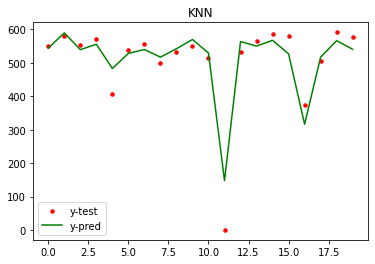

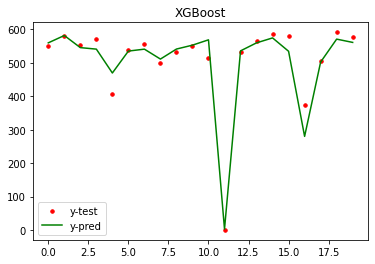

In [71]:
list_prediction = [y_predict_dep_test_knn,y_predict_dep_test_xgboost]
list_alg = ["KNN","XGBoost"]
for pred,alg in zip(list_prediction,list_alg):
    x_ax = range(len(dep_test_X))
    plt.scatter(x_ax, dep_test_Y,  s=12, label="y-test",c= "red")
    plt.plot(x_ax, pred, label="y-pred",c = "green")
    plt.legend()
    plt.title(alg)
    plt.show()

Comparaison Réelle & Prediction pour le deployement sample

In [70]:
prediction = pd.DataFrame(list(zip(dep_test_Y["PUISSANCE ValueY"],knn_model.predict(dep_test_X).T.tolist()[0],model.predict(dep_test_X).T.tolist())), columns = ['Puissance Réelle','Prediction KNN','Prediction XGBoost'])
prediction

,Puissance Réelle,Prediction KNN,Prediction XGBoost
0,549.782694,544.234323,560.050232
1,581.796693,589.830622,582.028015
2,552.591837,539.732503,545.748535
3,570.324871,555.795343,541.233276
4,407.553374,483.351256,469.815674
5,539.915630,528.427729,535.413086
6,556.870014,540.173117,541.165039
7,498.817430,517.172337,511.470490
8,533.192986,542.381912,541.438782
9,551.246553,570.079707,553.127136


In [ ]:
prediction.to_excel("prediction_3_value_per_day.xlsx")